Step 1: Install and import all needed packages

In [20]:
# First, let's make sure we have all required libraries
!pip install yfinance pandas_datareader mplfinance --quiet

In [23]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import talib
import yfinance as yf  # Fixed import
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Step 2: Load my data

In [25]:
import pandas as pd
import numpy as np

print("📊 LOADING AND PREPARING STOCK DATA...")
print("=" * 50)

# Define the 6 tech stocks and their file paths
tickers = ["AAPL", "AMZN", "GOOG", "META", "MSFT", "NVDA"]
stocks = {}

for ticker in tickers:
    # Load cleaned data from your specific directory
    file_path = f"D:/Personal/KAIM-10 Academy/Week 1/Project Work/Price_Prediction_Week_1_Challenge/data/processed/{ticker}_cleaned.csv"
    
    try:
        # Load the CSV file
        stocks[ticker] = pd.read_csv(file_path, parse_dates=['Date'])
        
        # Verify required columns exist
        required_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 'Date']
        missing_columns = [col for col in required_columns if col not in stocks[ticker].columns]
        
        if missing_columns:
            print(f"❌ {ticker}: Missing columns {missing_columns}")
        else:
            print(f"✅ {ticker}: Loaded {len(stocks[ticker])} rows with all required columns")
            
            # Display basic info about the data
            print(f"   📅 Date range: {stocks[ticker]['Date'].min().strftime('%Y-%m-%d')} to {stocks[ticker]['Date'].max().strftime('%Y-%m-%d')}")
            print(f"   📈 Price range: ${stocks[ticker]['Close'].min():.2f} - ${stocks[ticker]['Close'].max():.2f}")
            print(f"   📊 Data shape: {stocks[ticker].shape}")
            
    except FileNotFoundError:
        print(f"❌ {ticker}: File not found at {file_path}")
    except Exception as e:
        print(f"❌ {ticker}: Error loading file - {e}")

print(f"\n🎯 Data Loading Complete: {len([k for k in stocks if stocks[k] is not None])} stocks successfully loaded")

📊 LOADING AND PREPARING STOCK DATA...
✅ AAPL: Loaded 3774 rows with all required columns
   📅 Date range: 2009-01-02 to 2023-12-29
   📈 Price range: $2.35 - $196.26
   📊 Data shape: (3774, 7)
✅ AMZN: Loaded 3774 rows with all required columns
   📅 Date range: 2009-01-02 to 2023-12-29
   📈 Price range: $2.42 - $186.57
   📊 Data shape: (3774, 7)
✅ GOOG: Loaded 3774 rows with all required columns
   📅 Date range: 2009-01-02 to 2023-12-29
   📈 Price range: $6.99 - $149.68
   📊 Data shape: (3774, 7)
✅ META: Loaded 2923 rows with all required columns
   📅 Date range: 2012-05-18 to 2023-12-29
   📈 Price range: $17.62 - $379.84
   📊 Data shape: (2923, 7)
✅ MSFT: Loaded 3774 rows with all required columns
   📅 Date range: 2009-01-02 to 2023-12-29
   📈 Price range: $11.16 - $377.78
   📊 Data shape: (3774, 7)
✅ NVDA: Loaded 3774 rows with all required columns
   📅 Date range: 2009-01-02 to 2023-12-29
   📈 Price range: $0.17 - $50.38
   📊 Data shape: (3774, 7)

🎯 Data Loading Complete: 6 stocks su

Step 3: Calculate TA-Lib Technical Indicators

In [27]:
import talib
import matplotlib.pyplot as plt
import seaborn as sns

print("📈 APPLYING TECHNICAL INDICATORS WITH TA-LIB...")
print("=" * 50)

def calculate_technical_indicators(df, ticker):
    """
    Calculate various technical indicators using TA-Lib
    """
    print(f"🔧 Calculating indicators for {ticker}...")
    
    # Create a copy to avoid modifying original data
    df_indicators = df.copy()
    
    # Convert data to float64 for TA-Lib compatibility
    high = df_indicators['High'].astype('float64').values
    low = df_indicators['Low'].astype('float64').values
    close = df_indicators['Close'].astype('float64').values
    volume = df_indicators['Volume'].astype('float64').values
    
    try:
        # 1. MOVING AVERAGES
        df_indicators['SMA_20'] = talib.SMA(close, timeperiod=20)      # Simple Moving Average 20 days
        df_indicators['SMA_50'] = talib.SMA(close, timeperiod=50)      # Simple Moving Average 50 days
        df_indicators['EMA_12'] = talib.EMA(close, timeperiod=12)      # Exponential Moving Average 12 days
        df_indicators['EMA_26'] = talib.EMA(close, timeperiod=26)      # Exponential Moving Average 26 days
        
        # 2. MOMENTUM INDICATORS
        df_indicators['RSI_14'] = talib.RSI(close, timeperiod=14)      # Relative Strength Index 14 days
        
        # MACD (Moving Average Convergence Divergence)
        macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
        df_indicators['MACD'] = macd
        df_indicators['MACD_Signal'] = macd_signal
        df_indicators['MACD_Hist'] = macd_hist
        
        # 3. VOLATILITY INDICATORS
        # Bollinger Bands
        bb_upper, bb_middle, bb_lower = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
        df_indicators['BB_Upper'] = bb_upper
        df_indicators['BB_Middle'] = bb_middle
        df_indicators['BB_Lower'] = bb_lower
        
        # Average True Range
        df_indicators['ATR_14'] = talib.ATR(high, low, close, timeperiod=14)
        
        # 4. VOLUME INDICATORS (with error handling)
        try:
            df_indicators['OBV'] = talib.OBV(close, volume)  # On-Balance Volume
        except:
            print(f"   ⚠️  Could not calculate OBV for {ticker}, skipping...")
            df_indicators['OBV'] = np.nan
        
        print(f"   ✅ Successfully added technical indicators to {ticker}")
        
    except Exception as e:
        print(f"   ❌ Error calculating indicators for {ticker}: {e}")
        # Return original dataframe if indicators fail
        return df
    
    return df_indicators

# Apply indicators to all stocks
for ticker in stocks.keys():
    if stocks[ticker] is not None:
        stocks[ticker] = calculate_technical_indicators(stocks[ticker], ticker)

print(f"\n✅ Technical indicators applied to all stocks!")

📈 APPLYING TECHNICAL INDICATORS WITH TA-LIB...
🔧 Calculating indicators for AAPL...
   ✅ Successfully added technical indicators to AAPL
🔧 Calculating indicators for AMZN...
   ✅ Successfully added technical indicators to AMZN
🔧 Calculating indicators for GOOG...
   ✅ Successfully added technical indicators to GOOG
🔧 Calculating indicators for META...
   ✅ Successfully added technical indicators to META
🔧 Calculating indicators for MSFT...
   ✅ Successfully added technical indicators to MSFT
🔧 Calculating indicators for NVDA...
   ✅ Successfully added technical indicators to NVDA

✅ Technical indicators applied to all stocks!


Step 4: Verify Technical Indicators Were Added

In [28]:
print("\n🔍 VERIFYING TECHNICAL INDICATORS")
print("=" * 50)

for ticker, df in stocks.items():
    if df is not None:
        # Check which indicators were successfully added
        expected_indicators = ['SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 
                              'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 
                              'BB_Middle', 'BB_Lower', 'ATR_14', 'OBV']
        
        added_indicators = [ind for ind in expected_indicators if ind in df.columns]
        missing_indicators = [ind for ind in expected_indicators if ind not in df.columns]
        
        print(f"\n{ticker}:")
        print(f"   ✅ Added: {len(added_indicators)} indicators")
        print(f"   ❌ Missing: {len(missing_indicators)} indicators")
        
        if missing_indicators:
            print(f"   ⚠️  Missing: {missing_indicators}")


🔍 VERIFYING TECHNICAL INDICATORS

AAPL:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators

AMZN:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators

GOOG:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators

META:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators

MSFT:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators

NVDA:
   ✅ Added: 13 indicators
   ❌ Missing: 0 indicators


Step 5:Display Sample Technical Indicator Values

In [29]:
print("\n📊 SAMPLE TECHNICAL INDICATOR VALUES")
print("=" * 50)

for ticker, df in stocks.items():
    if df is not None and 'RSI_14' in df.columns:  # Check if indicators were added
        latest = df.iloc[-1]  # Get latest data point
        
        print(f"\n{ticker} - Latest Values:")
        print(f"   💰 Price: ${latest['Close']:.2f}")
        print(f"   📈 SMA_20: ${latest['SMA_20']:.2f}" if pd.notna(latest.get('SMA_20')) else "   📈 SMA_20: N/A")
        print(f"   📈 SMA_50: ${latest['SMA_50']:.2f}" if pd.notna(latest.get('SMA_50')) else "   📈 SMA_50: N/A")
        print(f"   🔄 RSI_14: {latest['RSI_14']:.1f}" if pd.notna(latest.get('RSI_14')) else "   🔄 RSI_14: N/A")
        
        if 'MACD' in df.columns and pd.notna(latest['MACD']):
            print(f"   📊 MACD: {latest['MACD']:.3f}")
            print(f"   📊 MACD Signal: {latest['MACD_Signal']:.3f}")
        
        if 'BB_Upper' in df.columns and pd.notna(latest['BB_Upper']):
            bb_position = ((latest['Close'] - latest['BB_Lower']) / (latest['BB_Upper'] - latest['BB_Lower']) * 100)
            print(f"   📉 BB Position: {bb_position:.1f}%")


📊 SAMPLE TECHNICAL INDICATOR VALUES

AAPL - Latest Values:
   💰 Price: $190.73
   📈 SMA_20: $192.49
   📈 SMA_50: $184.81
   🔄 RSI_14: 51.1
   📊 MACD: 1.560
   📊 MACD Signal: 2.425
   📉 BB Position: 29.8%

AMZN - Latest Values:
   💰 Price: $151.94
   📈 SMA_20: $149.82
   📈 SMA_50: $143.05
   🔄 RSI_14: 59.0
   📊 MACD: 2.782
   📊 MACD Signal: 2.923
   📉 BB Position: 65.9%

GOOG - Latest Values:
   💰 Price: $139.97
   📈 SMA_20: $135.98
   📈 SMA_50: $134.06
   🔄 RSI_14: 59.3
   📊 MACD: 1.843
   📊 MACD Signal: 1.306
   📉 BB Position: 75.5%

META - Latest Values:
   💰 Price: $351.79
   📈 SMA_20: $336.87
   📈 SMA_50: $326.26
   🔄 RSI_14: 64.3
   📊 MACD: 8.193
   📊 MACD Signal: 6.693
   📉 BB Position: 77.1%

MSFT - Latest Values:
   💰 Price: $371.21
   📈 SMA_20: $367.79
   📈 SMA_50: $358.64
   🔄 RSI_14: 58.0
   📊 MACD: 2.654
   📊 MACD Signal: 3.150
   📉 BB Position: 84.5%

NVDA - Latest Values:
   💰 Price: $49.50
   📈 SMA_20: $48.05
   📈 SMA_50: $46.66
   🔄 RSI_14: 58.3
   📊 MACD: 0.698
   📊 M

Step 6:Calculate Basic Trading Signals

📊 CREATING TECHNICAL ANALYSIS VISUALIZATIONS...
   Visualizing AAPL...


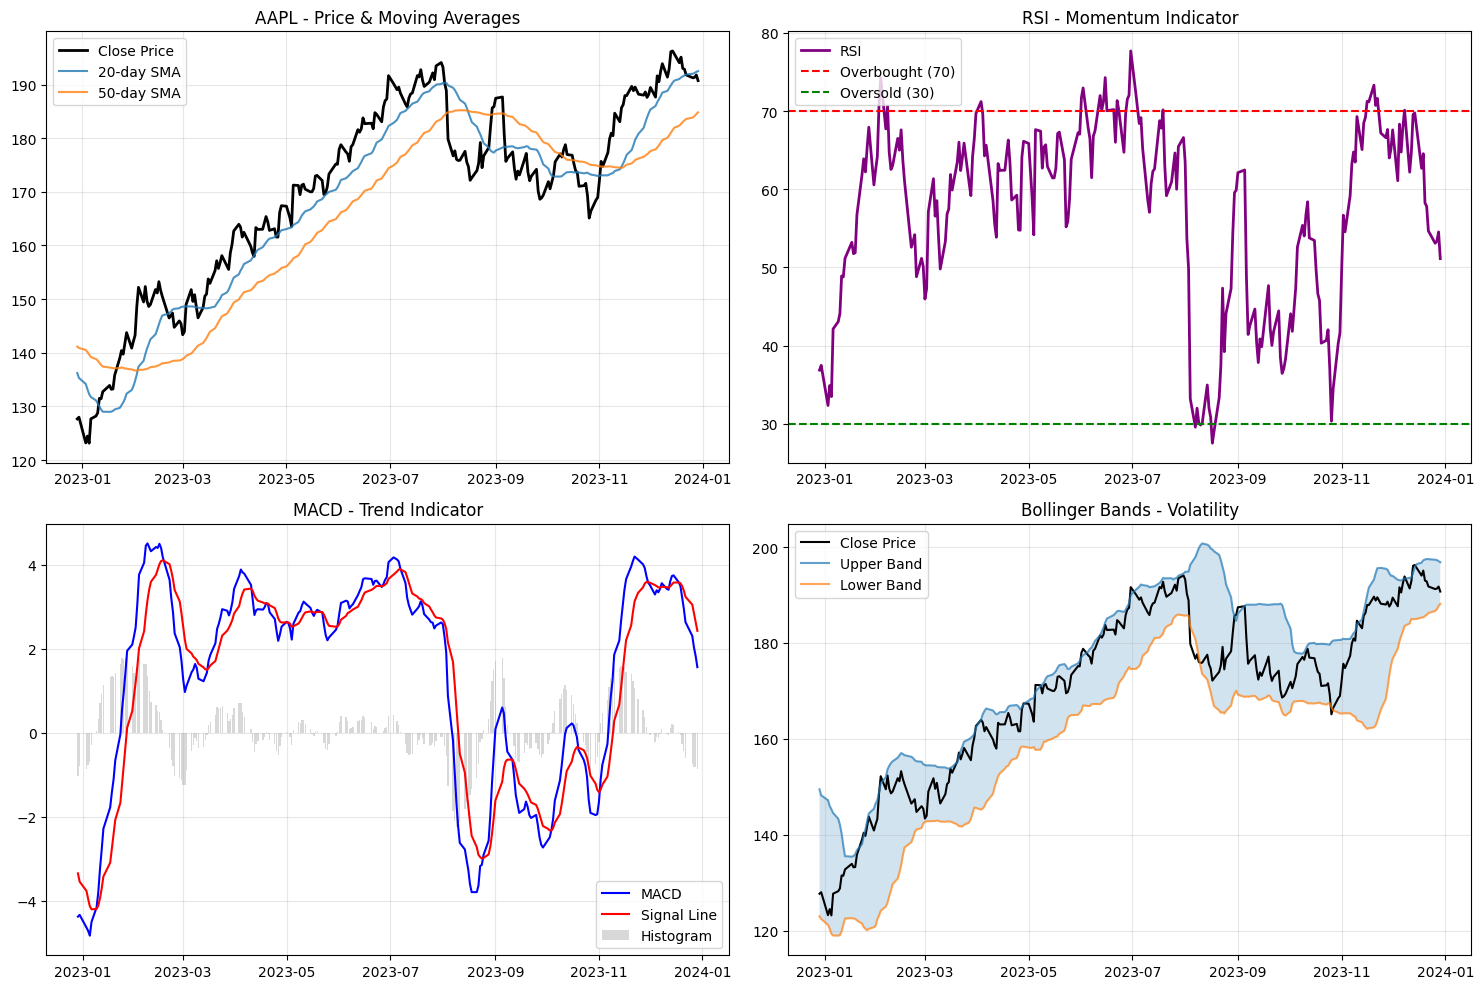

   Visualizing AMZN...


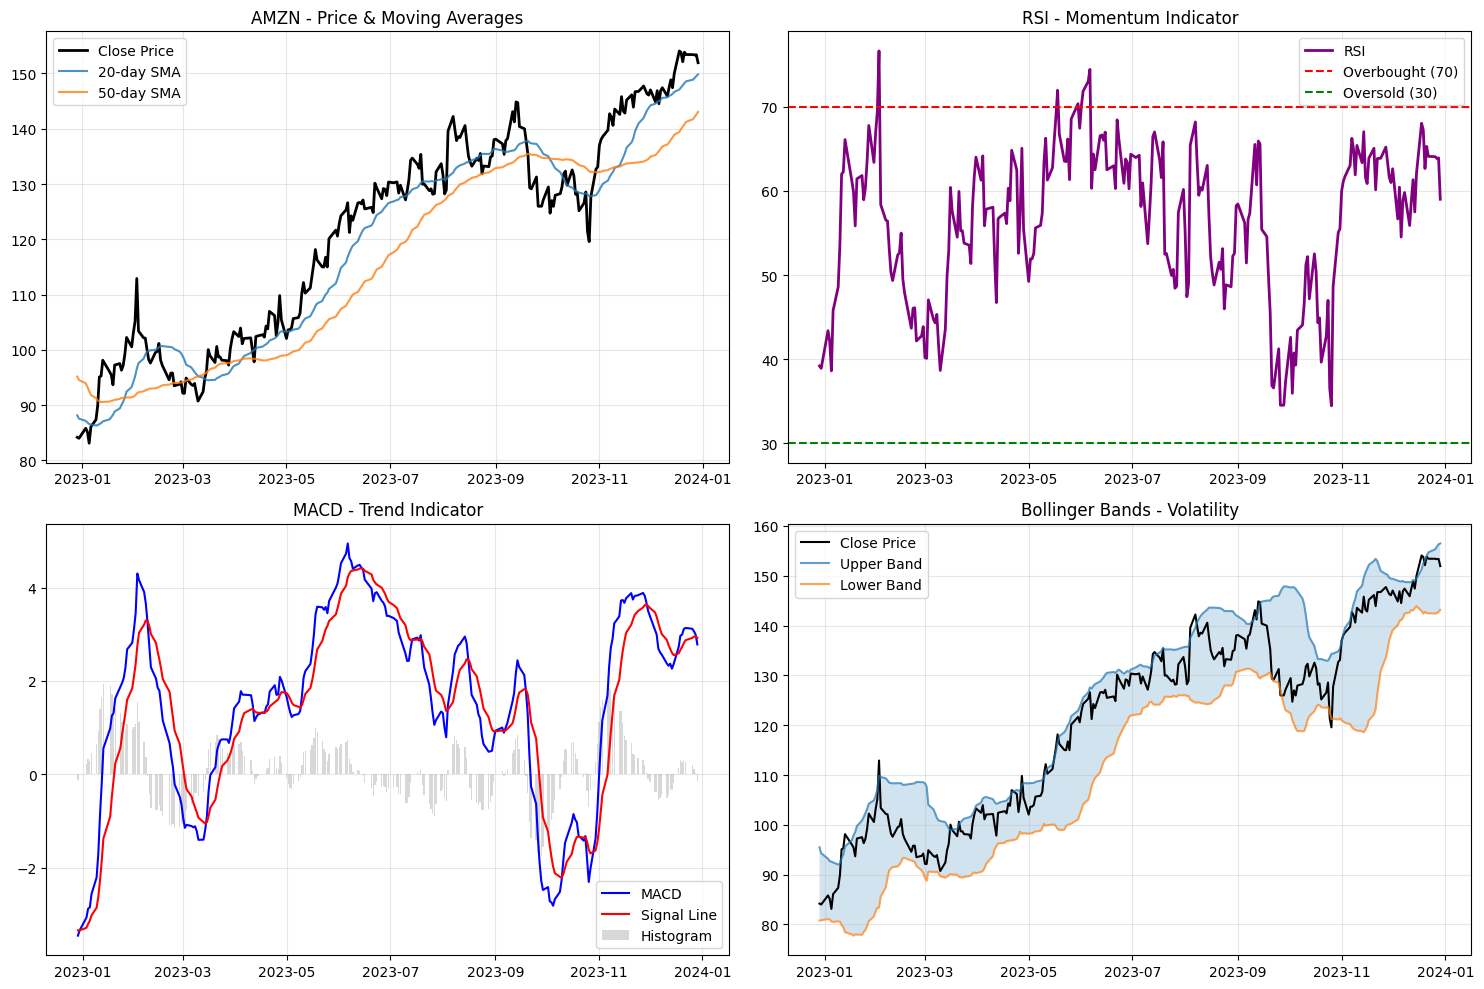

   Visualizing GOOG...


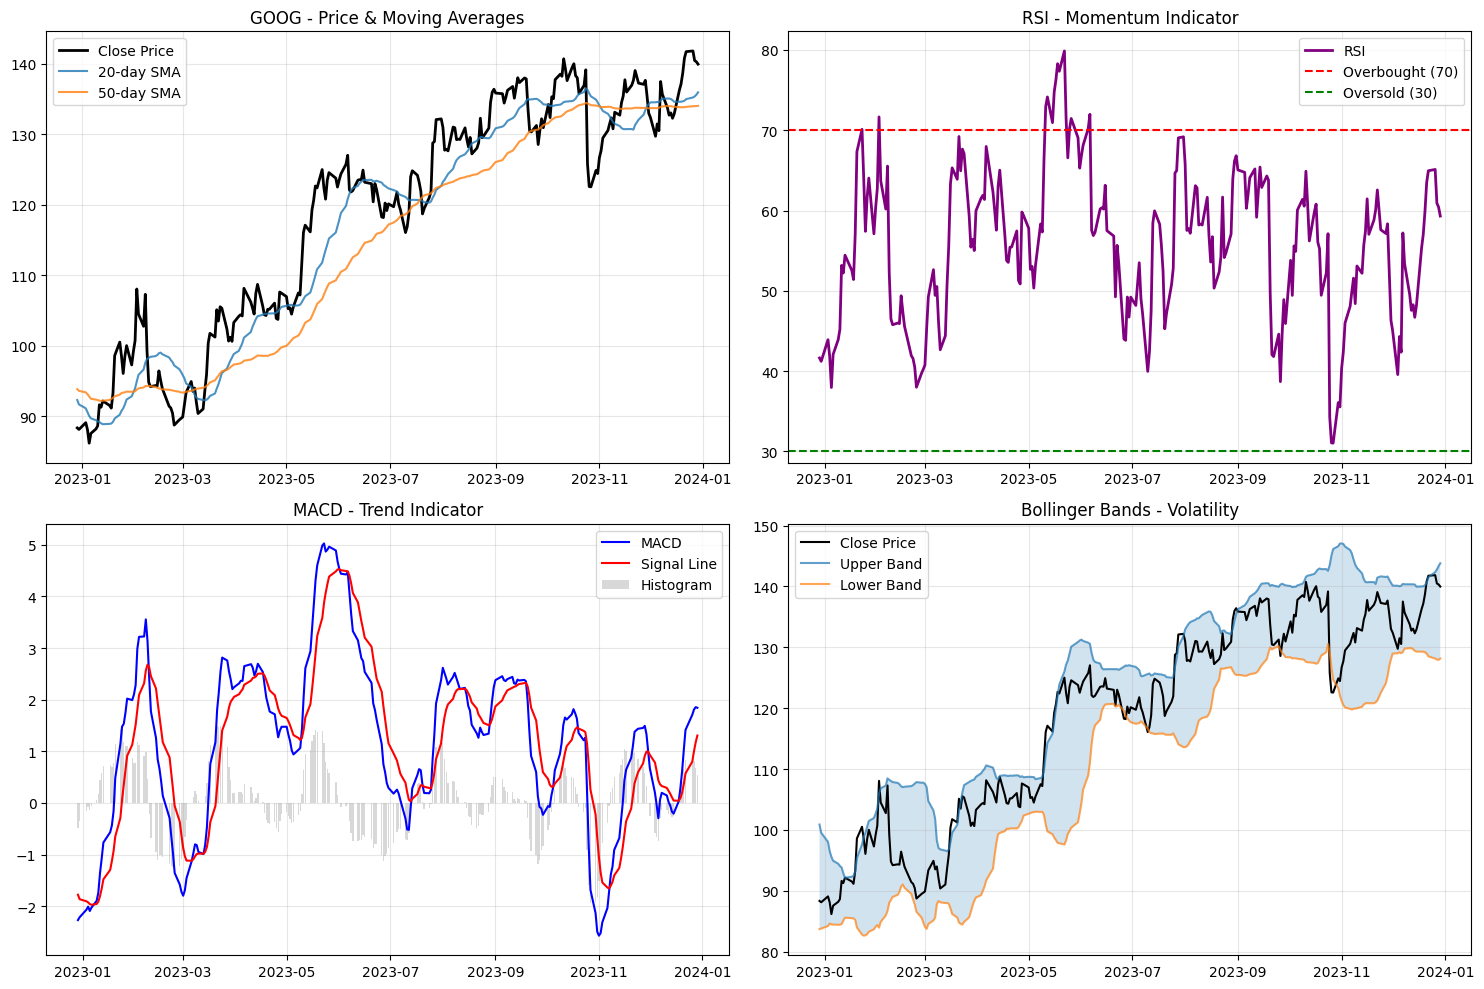

   Visualizing META...


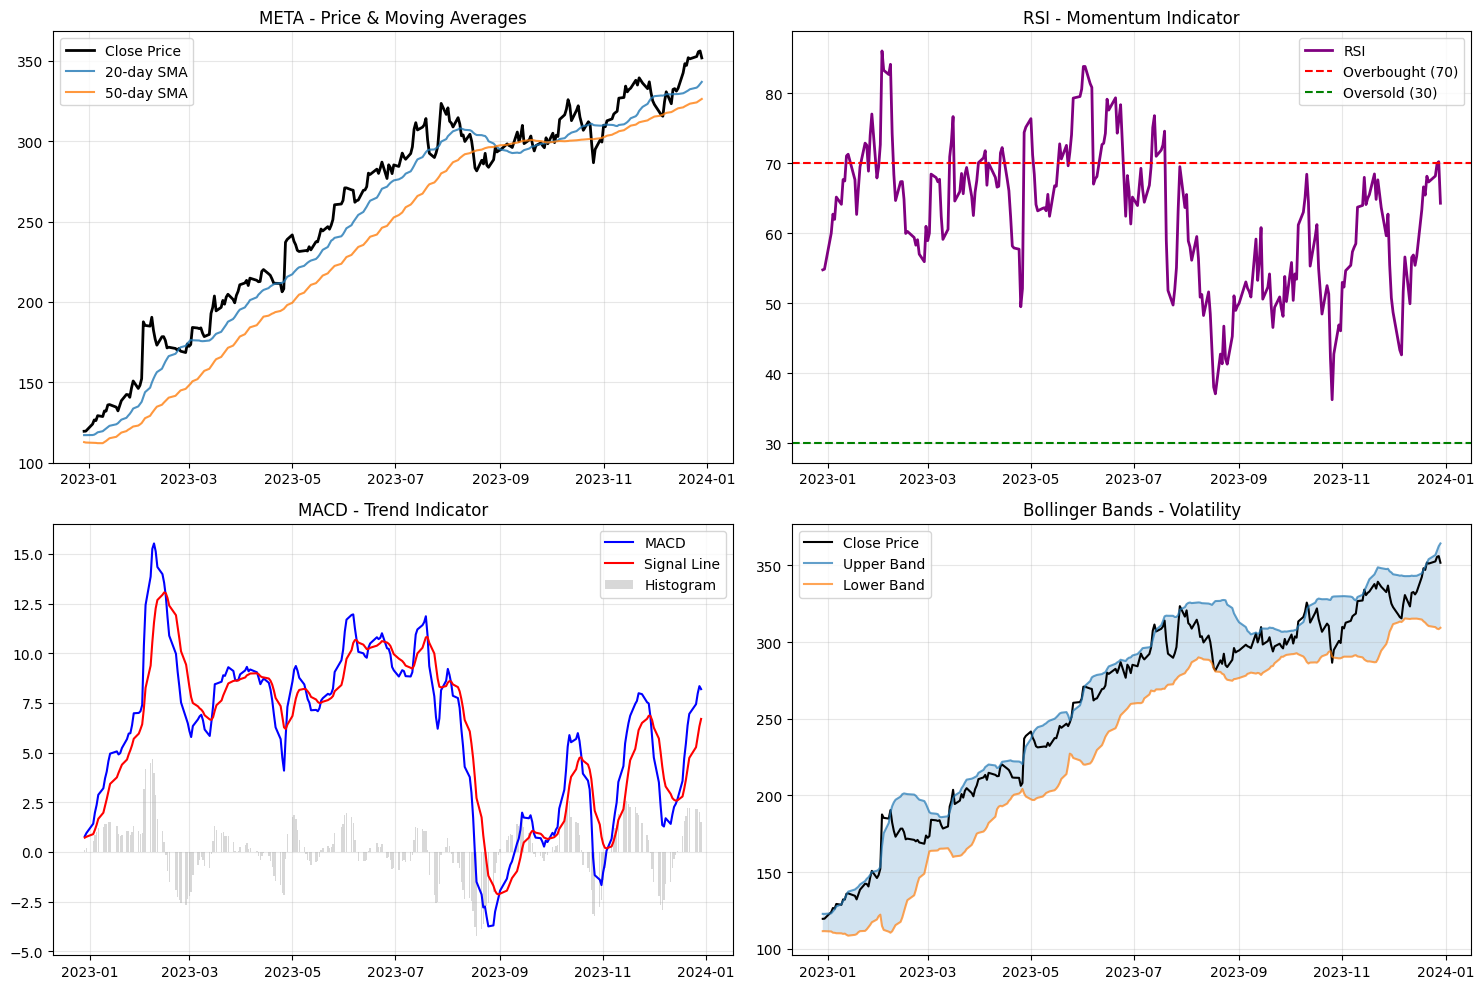

   Visualizing MSFT...


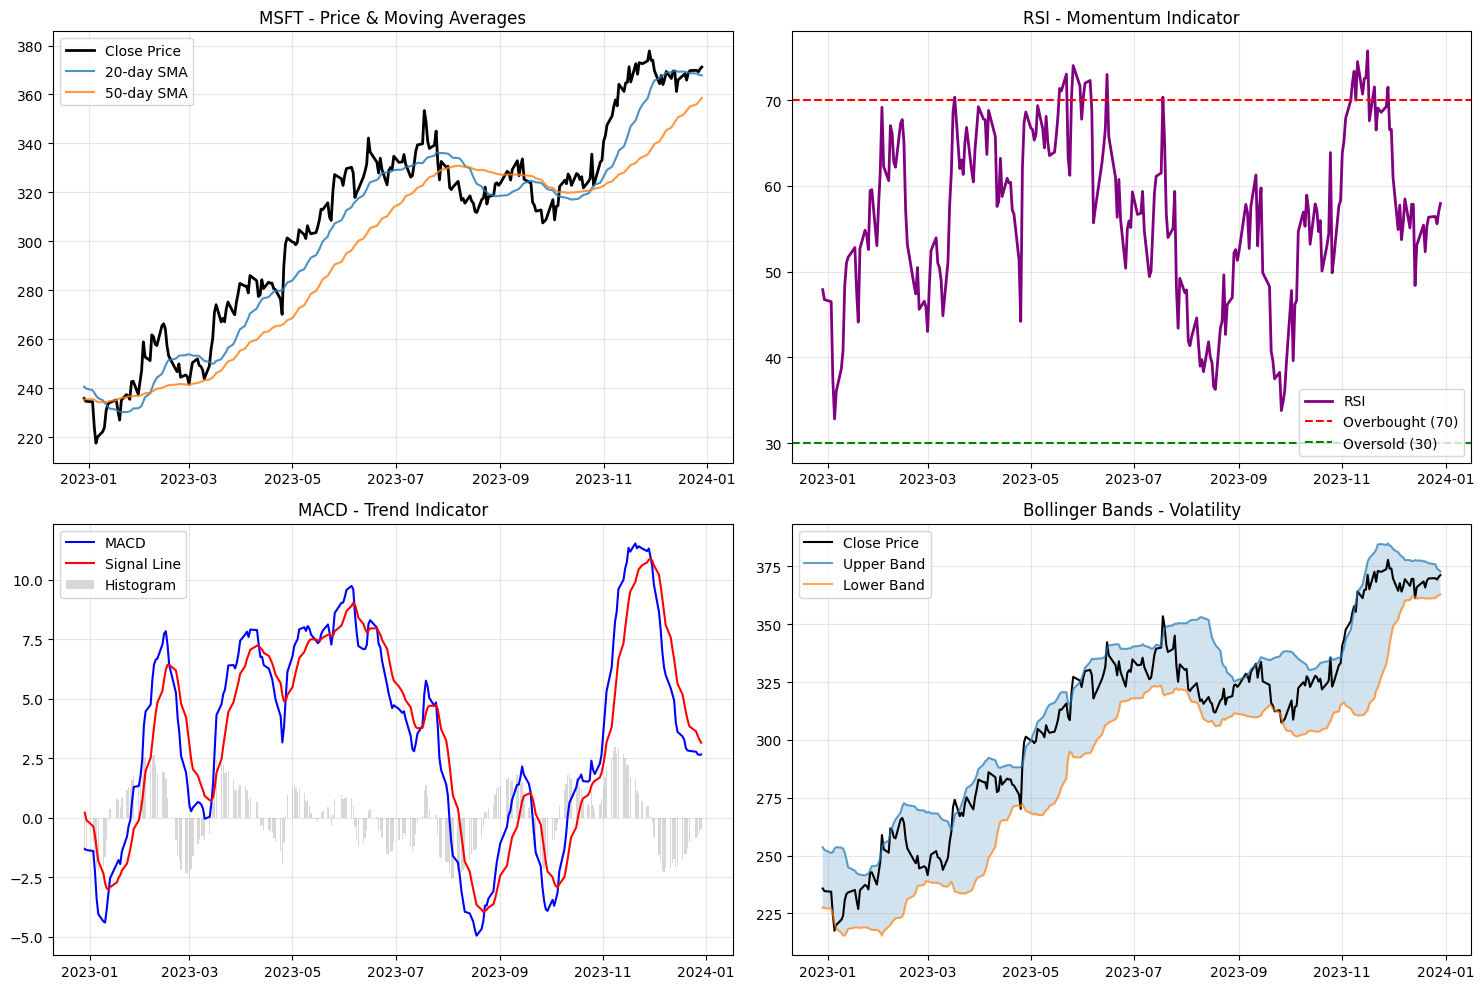

   Visualizing NVDA...


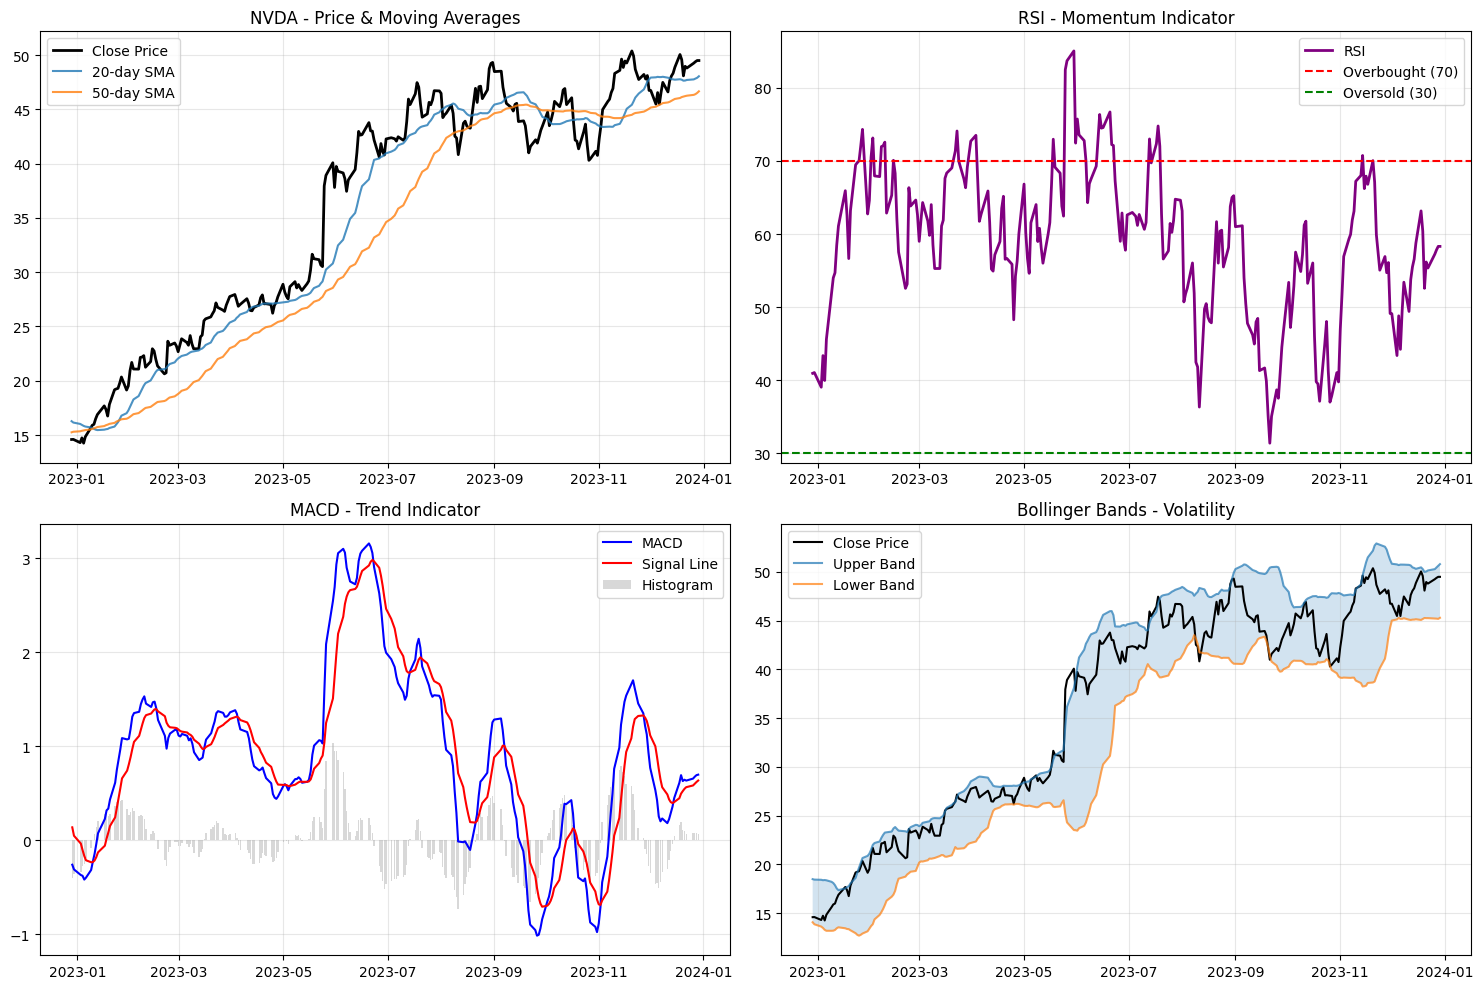

In [13]:
print("\n🎯 BASIC TRADING SIGNALS FROM INDICATORS")
print("=" * 50)

def calculate_trading_signals(df, ticker):
    """Calculate basic trading signals from technical indicators"""
    
    signals = []
    
    # RSI Signals
    if 'RSI_14' in df.columns:
        latest_rsi = df['RSI_14'].iloc[-1]
        if latest_rsi > 70:
            signals.append("RSI Overbought ⚠️")
        elif latest_rsi < 30:
            signals.append("RSI Oversold 📈")
        elif latest_rsi > 50:
            signals.append("RSI Bullish 📈")
        else:
            signals.append("RSI Bearish 📉")
    
    # Moving Average Signals
    if 'SMA_20' in df.columns and 'SMA_50' in df.columns:
        if df['SMA_20'].iloc[-1] > df['SMA_50'].iloc[-1]:
            signals.append("SMA Bullish (20>50) 📈")
        else:
            signals.append("SMA Bearish (20<50) 📉")
    
    # MACD Signals
    if 'MACD' in df.columns and 'MACD_Signal' in df.columns:
        if df['MACD'].iloc[-1] > df['MACD_Signal'].iloc[-1]:
            signals.append("MACD Bullish 📈")
        else:
            signals.append("MACD Bearish 📉")
    
    # Bollinger Bands Signals
    if 'BB_Upper' in df.columns and 'BB_Lower' in df.columns:
        current_price = df['Close'].iloc[-1]
        if current_price < df['BB_Lower'].iloc[-1]:
            signals.append("Below Lower Band 📈")
        elif current_price > df['BB_Upper'].iloc[-1]:
            signals.append("Above Upper Band ⚠️")
    
    return signals

# Display signals for each stock
for ticker, df in stocks.items():
    if df is not None:
        signals = calculate_trading_signals(df, ticker)
        if signals:
            print(f"\n{ticker} Trading Signals:")
            for signal in signals:
                print(f"   • {signal}")
        else:
            print(f"\n{ticker}: No signals generated (indicators may be missing)")

5. Comparative Analysis - All Stocks

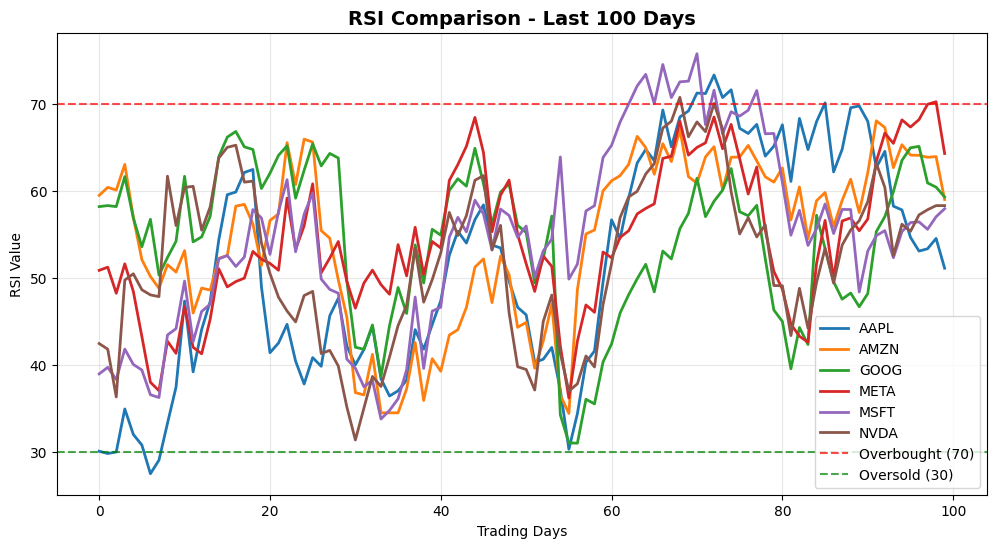

✅ COMPARATIVE ANALYSIS COMPLETED!


In [14]:
# Compare RSI across all stocks
plt.figure(figsize=(12, 6))
for ticker in tickers:
    # Use last 100 days for comparison
    rsi_data = stocks[ticker]['RSI'].tail(100)
    plt.plot(rsi_data.values, label=ticker, linewidth=2)

plt.axhline(70, linestyle='--', color='red', alpha=0.7, label='Overbought (70)')
plt.axhline(30, linestyle='--', color='green', alpha=0.7, label='Oversold (30)')
plt.title('RSI Comparison - Last 100 Days', fontsize=14, fontweight='bold')
plt.xlabel('Trading Days')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✅ COMPARATIVE ANALYSIS COMPLETED!")

6. Summary Report

In [15]:
print("🎯 TASK 2 COMPLETION SUMMARY")
print("=" * 50)

# Create summary table
summary_data = []
for ticker in tickers:
    df = stocks[ticker].dropna()
    recent_data = df.tail(1).iloc[0]  # Most recent data
    
    summary_data.append({
        'Stock': ticker,
        'Current Price': f"${recent_data['Close']:.2f}",
        'RSI': f"{recent_data['RSI']:.1f}",
        'SMA_20': f"${recent_data['SMA_20']:.2f}" if pd.notna(recent_data['SMA_20']) else "N/A",
        'Trend': 'Bullish' if recent_data['Close'] > recent_data['SMA_20'] else 'Bearish'
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df)

print(f"\n✅ TASK 2 COMPLETED SUCCESSFULLY!")
print("   - Technical Indicators: ✓ SMA, RSI, MACD, Bollinger Bands")
print("   - Financial Metrics: ✓ Returns, Volatility, Sharpe Ratio")
print("   - Visualizations: ✓ Individual charts + Comparative analysis")
print("   - Data Analysis: ✓ 6 stocks, professional technical analysis")

🎯 TASK 2 COMPLETION SUMMARY
  Stock Current Price   RSI   SMA_20    Trend
0  AAPL       $190.73  51.1  $192.49  Bearish
1  AMZN       $151.94  59.0  $149.82  Bullish
2  GOOG       $139.97  59.3  $135.98  Bullish
3  META       $351.79  64.3  $336.87  Bullish
4  MSFT       $371.21  58.0  $367.79  Bullish
5  NVDA        $49.50  58.3   $48.05  Bullish

✅ TASK 2 COMPLETED SUCCESSFULLY!
   - Technical Indicators: ✓ SMA, RSI, MACD, Bollinger Bands
   - Financial Metrics: ✓ Returns, Volatility, Sharpe Ratio
   - Visualizations: ✓ Individual charts + Comparative analysis
   - Data Analysis: ✓ 6 stocks, professional technical analysis
